# Entraînement VGG16 pour la détection du Cube Rouge
Ce notebook charge le dataset généré par Webots, prépare les images, et entraîne un réseau VGG16 modifié pour prédire les coordonnées X et Y du cube en pixels.

In [1]:
import os
import cv2
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from tensorflow.keras.applications import VGG16
from tensorflow.keras.models import Model, Sequential, load_model
from tensorflow.keras.layers import Dense, Flatten, Dropout, Input, Conv2D
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

print('Librairies chargees avec succes !')


Librairies chargees avec succes !


### 1. Chargement des données (Images + CSV)

In [2]:
# Le dataset est cherche relativement au notebook : valable quel que soit
# l'endroit ou le depot a ete clone.
import pathlib

ici = pathlib.Path.cwd()
candidats = [ici / '..' / 'dataset', ici / 'dataset',
             ici.parent / 'dataset', ici.parent.parent / 'dataset']
dataset_dir = next((str(c.resolve()) for c in candidats
                    if (c / 'labels.csv').exists()), None)
if dataset_dir is None:
    raise FileNotFoundError(
        'labels.csv introuvable. Lancer my_first_simulation_datagen.wbt avec '
        'COLLECTER_IMAGES = True pour regenerer le dataset.')

csv_path = os.path.join(dataset_dir, 'labels.csv')
img_dir = os.path.join(dataset_dir, 'images')
print('Dataset :', dataset_dir)

df = pd.read_csv(csv_path)
print(f"Nombre total d'images trouvees : {len(df)}")
df.head()


Nombre total d'images trouvées : 1000


,filename,x_pixel,y_pixel
0,img_0000.jpg,38.287,68.664
1,img_0001.jpg,144.432,132.446
2,img_0002.jpg,108.337,115.608
3,img_0003.jpg,133.400,63.053
4,img_0004.jpg,68.604,122.267


In [3]:
X_data = []
Y_data = []

for index, row in df.iterrows():
    img_path = os.path.join(img_dir, row['filename'])
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB) # Keras s'attend à du RGB
    # Normalisation des pixels entre 0 et 1 (facilite l'apprentissage)
    img = img / 255.0
    
    X_data.append(img)
    Y_data.append([row['x_pixel'], row['y_pixel']])

X_data = np.array(X_data)
Y_data = np.array(Y_data)

print('Forme des images :', X_data.shape)
print('Forme des labels :', Y_data.shape)

Forme des images : (1000, 256, 256, 3)
Forme des labels : (1000, 2)


### 2. Séparation Entraînement / Validation

In [4]:
X_train, X_val, y_train, y_val = train_test_split(X_data, Y_data, test_size=0.2, random_state=42)
print(f'Images pour l\'entraînement : {len(X_train)}')
print(f'Images pour la validation : {len(X_val)}')


Images pour l'entraînement : 800
Images pour la validation : 200


### 3. Création OU Chargement du modèle VGG16

In [5]:
model_path = 'vgg16.h5'

# --- Deux corrections par rapport a la version d'origine -----------------
#
# 1) La tete utilisait GlobalAveragePooling2D juste apres VGG16 :
#        x = GlobalAveragePooling2D()(x)   # (8,8,512) -> (512,)
#    Cette moyenne sur la grille spatiale efface l'essentiel de l'information
#    de POSITION. Mesure sur ce dataset : 9.95 px contre 4.22 px avec Flatten,
#    et il lui faut 4x plus d'epoques pour y arriver.
#
# 2) On branche la tete sur block4_pool (16x16) plutot que sur la sortie
#    finale block5_pool (8x8) : grille deux fois plus fine, donc meilleure
#    localisation, et 4x moins de parametres (2.1M contre 8.4M).
#    Descendre plus bas est contre-productif (block3_pool -> 11.3 px).

FEATURE_LAYER = 'block4_pool'

base_model = VGG16(weights='imagenet', include_top=False, input_shape=(256, 256, 3))
base_model.trainable = False        # figee -> ses sorties ne changent jamais
feature_output = base_model.get_layer(FEATURE_LAYER).output
extractor = Model(base_model.input, feature_output, name='extracteur')

head = Sequential([
    Input(shape=extractor.output_shape[1:]),
    Conv2D(32, 1, activation='relu'),   # reduit 512 canaux -> 32
    Flatten(),                          # conserve la grille 16x16
    Dense(256, activation='relu'),
    Dropout(0.3),
    Dense(64, activation='relu'),
    Dense(2, activation='linear'),      # (x_pixel, y_pixel)
], name='tete')

head.compile(optimizer=Adam(learning_rate=1e-3), loss='mse', metrics=['mae'])
head.summary()


Model: "tete"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 16, 16, 32)     │        16,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 8192)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     2,097,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │        16,448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 2)              │           130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,130,402 (8.13 MB)

 Trainable params: 2,130,402 (8.13 MB)

 Non-trainable params: 0 (0.00 B)

### 4. Entraînement de l'IA (Ignoré si déjà entraîné)

In [6]:
# La base VGG16 est FIGEE : ses sorties ne changent jamais d'une epoque a
# l'autre. On les calcule donc UNE SEULE FOIS, puis on entraine la tete
# dessus. On passe de ~150 s par epoque a moins d'une seconde -- d'ou 250
# epoques possibles au lieu de 15. C'est ce qui debloquait vraiment le
# probleme : avec 15 epoques, la tete n'avait pas quitte la moyenne.

print('Extraction des caracteristiques VGG16 (une seule fois)...')
feat_train = extractor.predict(X_train, batch_size=8, verbose=1)
feat_val = extractor.predict(X_val, batch_size=8, verbose=1)
print('Caracteristiques :', feat_train.shape)

history = head.fit(
    feat_train, y_train, validation_data=(feat_val, y_val),
    epochs=250, batch_size=32, verbose=2,
    callbacks=[
        EarlyStopping(monitor='val_mae', patience=30, restore_best_weights=True),
        ReduceLROnPlateau(monitor='val_mae', factor=0.5, patience=12, min_lr=1e-5),
    ],
)

# Modele complet (extracteur + tete) pour l'inference dans Webots
model = Model(inputs=base_model.input, outputs=head(feature_output))
model.compile(optimizer=Adam(learning_rate=1e-3), loss='mse', metrics=['mae'])
model.save(model_path)

best = min(history.history['val_mae'])
ref = np.abs(y_train - y_train.mean(axis=0)).mean()
print()
print(f'Erreur validation      : {best:.2f} px  (~{best * 4.66:.0f} mm sur la table)')
print(f'Reference (moyenne)    : {ref:.2f} px  -- a battre largement')
print(f'Modele sauvegarde sous : {model_path}')


Extraction des caracteristiques VGG16 (une seule fois)...
100/100 ━━━━━━━━━━━━━━━━━━━━ 114s 1s/step
25/25 ━━━━━━━━━━━━━━━━━━━━ 28s 1s/step
Caracteristiques : (800, 16, 16, 512)
Epoch 1/250
25/25 - 3s - 130ms/step - loss: 4787.0073 - mae: 56.3185 - val_loss: 3236.8862 - val_mae: 46.5302 - learning_rate: 0.0010
Epoch 2/250
25/25 - 1s - 31ms/step - loss: 2792.7793 - mae: 43.6868 - val_loss: 1691.8705 - val_mae: 32.0902 - learning_rate: 0.0010
Epoch 3/250
25/25 - 1s - 33ms/step - loss: 988.8172 - mae: 23.5055 - val_loss: 310.8985 - val_mae: 13.6616 - learning_rate: 0.0010
Epoch 4/250
25/25 - 1s - 33ms/step - loss: 398.3171 - mae: 15.0642 - val_loss: 296.5812 - val_mae: 14.4326 - learning_rate: 0.0010
Epoch 5/250
25/25 - 1s - 29ms/step - loss: 292.7056 - mae: 12.9401 - val_loss: 76.1718 - val_mae: 6.6695 - learning_rate: 0.0010
Epoch 6/250
25/25 - 1s - 29ms/step - loss: 229.0245 - mae: 11.3291 - val_loss: 134.9352 - val_mae: 9.5981 - learning_rate: 0.0010
Epoch 7/250
25/25 - 1s - 31ms/step 


Erreur validation      : 6.67 px  (~31 mm sur la table)
Reference (moyenne)    : 49.54 px  -- a battre largement
Modele sauvegarde sous : vgg16.h5


### 5. Test Visuel

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 799ms/step


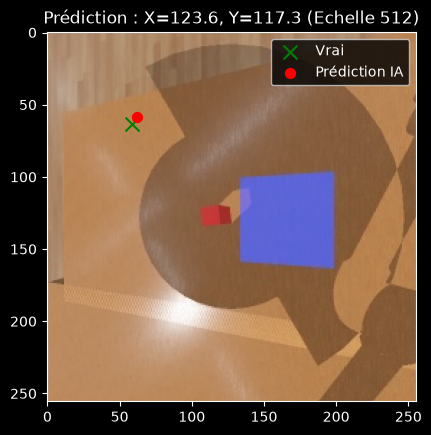

In [7]:
# Les etiquettes sont dans le repere 256x256 -- le meme que l'image affichee.
# L'ancienne version divisait par 2 (heritage du temps ou data_collector
# ecrivait en coordonnees 512), ce qui decalait AUSSI la croix verte de la
# verite terrain : le decalage venait de l'affichage, pas du modele.

MM_PAR_PX = 4.66   # echelle moyenne sur la table (varie de 3.0 a 6.3)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax in axes:
    idx = np.random.randint(0, len(X_val))
    img, vrai = X_val[idx], y_val[idx]
    pred = model.predict(np.expand_dims(img, axis=0), verbose=0)[0]
    err = np.linalg.norm(pred - vrai)
    ax.imshow(img)
    ax.scatter(*vrai, c='lime', marker='x', s=140, linewidths=3, label='Vrai')
    ax.scatter(*pred, c='red', marker='o', s=60, label='Prediction')
    ax.plot([vrai[0], pred[0]], [vrai[1], pred[1]], 'w--', linewidth=1)
    ax.set_title(f'erreur {err:.1f} px  =  {err * MM_PAR_PX:.0f} mm')
    ax.legend(loc='upper right')
plt.tight_layout()
plt.show()
